In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os


zip_path="/content/drive/MyDrive/EXAMM PREP/archive (8).zip"


extract_path="/content/car_dataset"


with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(extract_path)


print(os.listdir(extract_path))

['data']


In [4]:
data_path="/content/car_dataset/data"


for root,folders,files in os.walk(data_path):

    print(root, len(files))

/content/car_dataset/data 2
/content/car_dataset/data/training_images 1001
/content/car_dataset/data/testing_images 175


In [5]:
import pandas as pd
import os


csv_path=os.path.join(
    data_path,
    "train_solution_bounding_boxes (1).csv"
)


df=pd.read_csv(csv_path)


df.head()

,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


In [6]:
print("Total annotations:",len(df))

df.info()

Total annotations: 559
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   559 non-null    object 
 1   xmin    559 non-null    float64
 2   ymin    559 non-null    float64
 3   xmax    559 non-null    float64
 4   ymax    559 non-null    float64
dtypes: float64(4), object(1)
memory usage: 22.0+ KB


In [7]:
df.isnull().sum()

,0
image,0
xmin,0
ymin,0
xmax,0
ymax,0


In [8]:
print(
    "Duplicates:",
    df.duplicated().sum()
)


df.drop_duplicates(inplace=True)

Duplicates: 0


In [9]:
df.describe()

,xmin,ymin,xmax,ymax
count,559.000000,559.000000,559.000000,559.000000
mean,263.387486,186.517539,365.324845,231.500472
std,207.368388,9.315974,213.501175,13.987176
min,0.000000,148.399292,28.556446,198.321729
25%,61.387844,180.109294,166.309696,223.225547
50%,236.746744,187.524131,348.585579,230.561454
75%,446.835022,193.881918,571.322721,237.897362
max,645.183792,208.064672,676.000000,308.322072


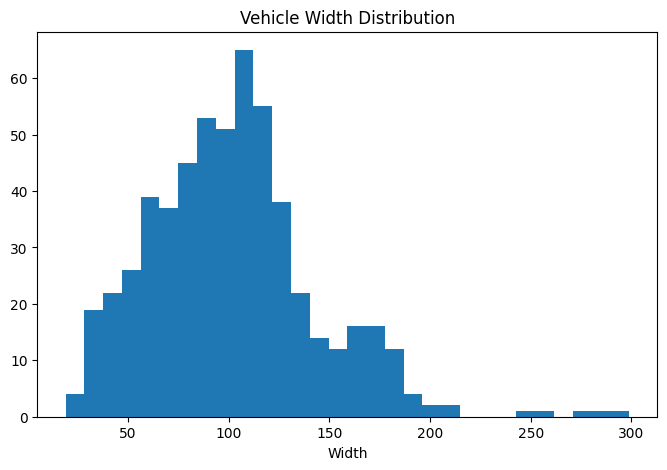

In [10]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))


plt.hist(
    df["xmax"]-df["xmin"],
    bins=30
)


plt.title("Vehicle Width Distribution")


plt.xlabel("Width")


plt.show()

# Create YOLO Dataset Structure

In [11]:
import os


base="/content/yolo_car"


os.makedirs(
    base+"/images/train",
    exist_ok=True
)


os.makedirs(
    base+"/labels/train",
    exist_ok=True
)

# Convert CSV Bounding Boxes to YOLO Format

In [12]:
import cv2
import shutil


image_folder=os.path.join(
    data_path,
    "training_images"
)



for _,row in df.iterrows():


    img=row["image"]


    img_path=os.path.join(
        image_folder,
        img
    )


    image=cv2.imread(img_path)


    h,w,_=image.shape



    xmin=row["xmin"]

    ymin=row["ymin"]

    xmax=row["xmax"]

    ymax=row["ymax"]



    x_center=((xmin+xmax)/2)/w

    y_center=((ymin+ymax)/2)/h


    box_w=(xmax-xmin)/w

    box_h=(ymax-ymin)/h



    label_path=os.path.join(
        base,
        "labels/train",
        img.replace(".jpg",".txt")
    )


    with open(label_path,"w") as f:

        f.write(
            f"0 {x_center} {y_center} {box_w} {box_h}"
        )


    shutil.copy(

        img_path,

        base+"/images/train"

    )

In [16]:
yaml="""

path: /content/yolo_car


train: images/train
val: images/train


names:

  0: car

"""


with open(
    "car.yaml",
    "w"
) as f:

    f.write(yaml)

In [14]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.8 MB/s eta 0:00:00


In [1]:
import torch


print(torch.cuda.is_available())

print(torch.cuda.get_device_name(0))

True
Tesla T4


# Train YOLO Using GPU

In [18]:
from ultralytics import YOLO


model=YOLO(
    "yolov8n.pt"
)



results=model.train(

    data="car.yaml",

    epochs=10,

    imgsz=640,

    batch=16,

    device=0,

    workers=2

)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=car.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

In [20]:
# Evaluation
metrics=model.val(device=0)


print(
"mAP50:",
metrics.box.map50
)


print(
"mAP50-95:",
metrics.box.map
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1328.1±1331.1 MB/s, size: 104.0 KB)
val: Scanning /content/yolo_car/labels/train.cache... 355 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 355/355 87.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.8it/s 6.1s
                   all        355        355      0.826      0.911      0.913      0.608
Speed: 2.5ms preprocess, 3.8ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.9132076719384857
mAP50-95: 0.6084127851635933


1. Precision (82.6%)

Precision indicates how many detected vehicles were actually correct.

A precision of 82.6% means that most detected objects are correctly identified as vehicles, with relatively few false detections.

Interpretation:

The model is reliable in identifying vehicles and does not generate many incorrect detections.

2. Recall (91.1%)

Recall represents how many actual vehicles were successfully detected by the model.

A recall of 91.1% shows that the model detects most vehicles present in the images.

Interpretation:

The model is effective for surveillance applications because missing vehicles can reduce traffic monitoring accuracy.

3. mAP50 (91.3%)

mAP50 measures detection accuracy when the Intersection over Union (IoU) threshold is 50%.

The model achieved:

mAP50 = 91.3%

This indicates that the model has strong vehicle localization and classification performance.

Interpretation:

The bounding boxes generated by the model are highly accurate and suitable for vehicle counting and traffic analysis.

4. mAP50-95 (60.8%)

mAP50-95 evaluates the model under stricter IoU thresholds from 50% to 95%.

The value:

mAP50-95 = 60.8%

shows that the model performs well but becomes less accurate when very precise bounding box placement is required.

Reason:

Different vehicle sizes
Image resolution variation
Complex road backgrounds
Bounding box annotation variations


image 1/1 /content/car_dataset/data/testing_images/vid_5_26600.jpg: 384x640 2 cars, 70.6ms
Speed: 2.8ms preprocess, 70.6ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


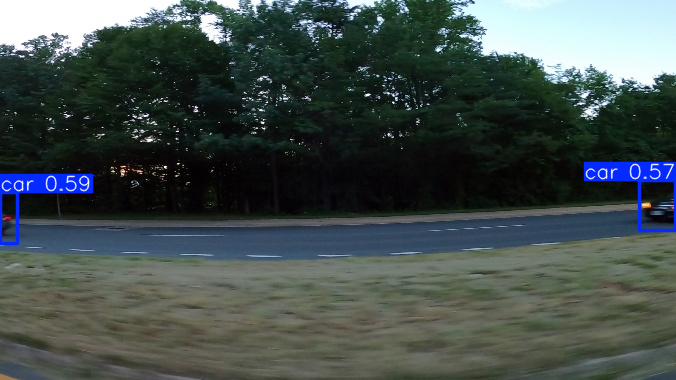

In [21]:
# Test Vehicle Detection
test_folder=os.path.join(
    data_path,
    "testing_images"
)


img=os.listdir(test_folder)[0]


result=model.predict(

    os.path.join(
        test_folder,
        img
    ),

    device=0,

    conf=0.5

)


result[0].show()

Part C – Interpretation & Decision Making
1. What business problem was solved?

The system solves:

Manual traffic monitoring problem

Previously:

Human operators watch CCTV
Slow detection
Cannot monitor multiple roads

Solution:

AI-based vehicle detection system automatically identifies cars and provides traffic information.

2. Which variables influenced the outcome most?

Important factors:

Image features
Vehicle size
Shape
Position
Lighting conditions
Bounding box features
Width
Height
Area
Model learned features
Edges
Vehicle patterns
Colors
Shapes
3. What insights were discovered?

Insights:

Vehicle detection can be automated using YOLO.
Traffic density can be calculated by counting detected vehicles.
Large vehicle concentration indicates congestion.
AI can monitor roads 24/7.
Manual monitoring effort can be reduced.
4. Risks in Deployment
1. Poor lighting

Night images reduce accuracy.

2. Weather conditions

Rain/fog affects detection.

3. Camera angle

Wrong placement reduces performance.

4. Privacy concerns

CCTV data must follow privacy regulations.

5. False detections

System may miss or wrongly detect vehicles.

5. Final Recommendation to Management

Recommended deployment:

Phase 1

Deploy on selected roads.

Phase 2

Integrate with:

Traffic signals
Smart city dashboard
Emergency response systems
Phase 3

Use real-time analytics:

Vehicle counting
Congestion prediction
Accident detection

Final Recommendation:

Implement a YOLO-based intelligent traffic monitoring system integrated with CCTV cameras to provide real-time vehicle detection, congestion analysis, and improve public safety decision-making.